<a href="https://colab.research.google.com/github/R-Anand123/fake-news-detector-streamlit/blob/main/Exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import string

from sklearn.model_selection import train_test_split

nltk.download('punkt' )
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Loading the DataSet

In [78]:
df_true = pd.read_csv("/content/drive/MyDrive/AI ML/Data/True.csv")

In [79]:
df_fake = pd.read_csv("/content/drive/MyDrive/AI ML/Data/Fake.csv")

#EDA (Both Fake and real)

In [80]:
df_true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [81]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [82]:
df_true['label'] = 'real'      # Reuters is generally credible
df_fake['label'] = 'fake'

In [83]:
df = pd.concat([df_true, df_fake], ignore_index=True)

In [84]:
df_true.shape

(21417, 5)

In [85]:
df_fake.shape

(23481, 5)

In [86]:
df_true.head(5)

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",real
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",real
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",real
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",real
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",real


In [87]:
df_fake.head(5)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


In [88]:
df_true.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


### Examining missing values

In [89]:
df_fake.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [90]:
df_true.describe()

,title,text,subject,date,label
count,21417,21417,21417,21417,21417
unique,20826,21192,2,716,1
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017",real
freq,14,8,11272,182,21417


In [91]:
df_fake.describe()

,title,text,subject,date,label
count,23481,23481,23481,23481,23481
unique,17903,17455,6,1681,1
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017",fake
freq,6,626,9050,46,23481


### Examining duplicated values

In [92]:

df_true.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
21412,False
21413,False
21414,False
21415,False


In [93]:
df_fake.duplicated().sum()

np.int64(3)

### Analyzing class distribution

In [94]:
class_dist = df['label'].value_counts()
print(class_dist)


label
fake    23481
real    21417
Name: count, dtype: int64


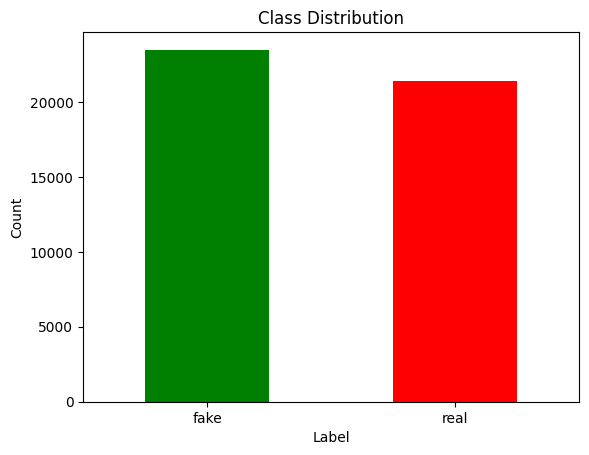

In [95]:
class_dist.plot(kind='bar', color=['green','red'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [96]:
df['label'].isna().sum()

np.int64(0)

###Exploring length size and frequency

count    44898.000000
mean        80.111720
std         25.379685
min          8.000000
25%         63.000000
50%         73.000000
75%         91.000000
max        286.000000
Name: title_length, dtype: float64


<Axes: >

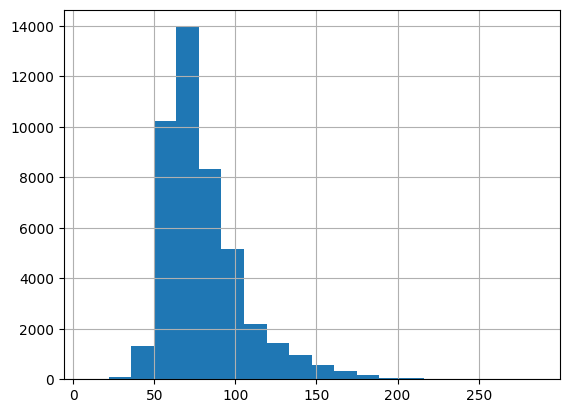

In [97]:
#  Title length
df['title_length'] = df['title'].fillna('').str.len()
print(df['title_length'].describe())
df['title_length'].hist(bins=20)



count    44898.000000
mean      2469.109693
std       2171.617091
min          1.000000
25%       1234.000000
50%       2186.000000
75%       3105.000000
max      51794.000000
Name: text_length, dtype: float64


<Axes: >

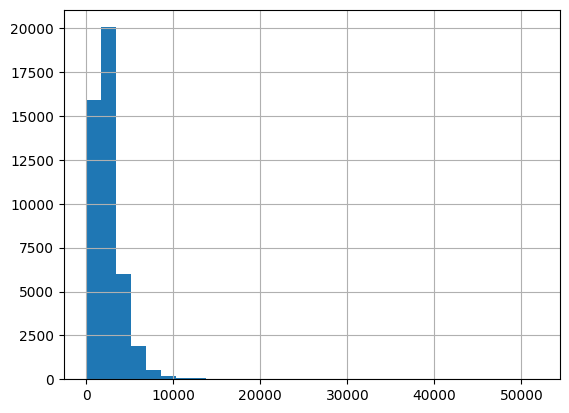

In [98]:
# Text length
df['text_length'] = df['text'].fillna('').str.len()
print(df['text_length'].describe())
df['text_length'].hist(bins=30)



count    44898.000000
mean       405.282284
std        351.265595
min          0.000000
25%        203.000000
50%        362.000000
75%        513.000000
max       8135.000000
Name: word_count, dtype: float64


<Axes: >

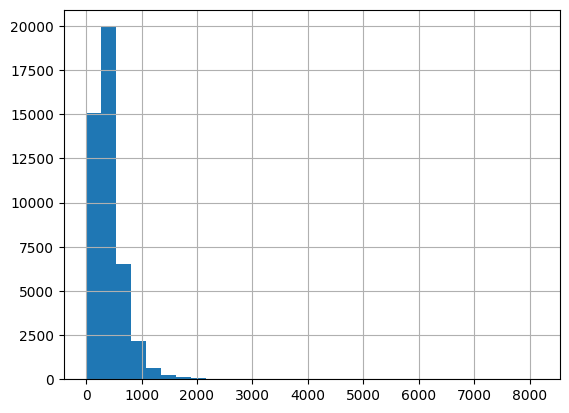

In [99]:
#  Word count
df['word_count'] = df['text'].fillna('').str.split().str.len()
print(df['word_count'].describe())
df['word_count'].hist(bins=30)

## NLP preprocessing

In [100]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

### Before cleaning

In [101]:
print(f"Original dataset shape: {df.shape}")
print(f"Sample text before cleaning:\n{df['text'].iloc[0][:200]}\n")

Original dataset shape: (44898, 8)
Sample text before cleaning:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 



### Conerting to lower case

In [102]:
df['text_cleaned'] = df['text'].str.lower()
df['title_cleaned'] = df['title'].str.lower()

In [103]:
url_pattern = r'http\S+|www\S+'
df['text_cleaned'] = df['text_cleaned'].str.replace(url_pattern, '', regex=True)
df['title_cleaned'] = df['title_cleaned'].str.replace(url_pattern, '', regex=True)

### Lemmatization

In [104]:
def lemmatize_text(text):
    tokens = text.split()
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized)

df['text_cleaned'] = df['text_cleaned'].apply(lemmatize_text)
df['title_cleaned'] = df['title_cleaned'].apply(lemmatize_text)

### Removing stopwords

In [111]:
def remove_stopwords(text):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

df['text_cleaned'] = df['text_cleaned'].apply(remove_stopwords)
df['title_cleaned'] = df['title_cleaned'].apply(remove_stopwords)
df['combined_text'] = df['title_cleaned'] + ' ' + df['text_cleaned']


In [112]:
print(f"\nCleaned dataset shape: {df.shape}\n")
print("Sample comparison (BEFORE vs AFTER):")
print(f"BEFORE:\n{df['text'].iloc[0][:200]}\n")
print(f"AFTER:\n{df['text_cleaned'].iloc[0][:200]}\n")

# Check for null/empty values
print(f"Null values in text_cleaned: {df['text_cleaned'].isna().sum()}")
print(f"Empty strings in text_cleaned: {(df['text_cleaned'] == '').sum()}")

# Display statistics
print(f"\nOriginal text length (avg): {df['text'].str.len().mean():.2f}")
print(f"Cleaned text length (avg): {df['text_cleaned'].str.len().mean():.2f}")

print(f"\nOriginal word count (avg): {df['text'].str.split().str.len().mean():.2f}")
print(f"Cleaned word count (avg): {df['text_cleaned'].str.split().str.len().mean():.2f}")

# Display sample cleaned data
print("\nSample cleaned data:")
print(df[['title_cleaned', 'text_cleaned', 'label']].head(3))


Cleaned dataset shape: (44898, 11)

Sample comparison (BEFORE vs AFTER):
BEFORE:
WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal 

AFTER:
washington (reuters) - head conservative republican faction u.s. congress, voted month huge expansion national debt pay tax cuts, called “fiscal conservative” sunday urged budget restraint 2018. keepi

Null values in text_cleaned: 0
Empty strings in text_cleaned: 715

Original text length (avg): 2469.11
Cleaned text length (avg): 1815.99

Original word count (avg): 405.28
Cleaned word count (avg): 242.81

Sample cleaned data:
                                       title_cleaned  \
0  u.s. budget fight looms, republican flip fisca...   
1  u.s. military accept transgender recruit monda...   
2  senior u.s. republican senator: 'let mr. muell...   

                                        text_cleaned l

### Vectorisation

In [113]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X = vectorizer.fit_transform(df['combined_text'])
y = df['label']
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {X.shape[1]}\n")

Feature matrix shape: (44898, 5000)
Number of features: 5000



### Train-Test split

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 35918
Test set size: 8980


## Model Building

In [124]:
models = {}
results = {}

#### Model 1 Logistic Regressor

In [119]:
# Model 1
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [139]:
from sklearn.preprocessing import LabelEncoder

# Convert string labels to numerical labels for ROC AUC calculation
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_pred_lr_encoded = le.transform(y_pred_lr)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_encoded, y_pred_lr_encoded):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.9879
Precision: 0.9879
Recall: 0.9879
F1-Score: 0.9879
ROC AUC: 0.9880

Classification Report:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      4696
        real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [126]:
models['Logistic Regression'] = lr_model


In [142]:
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, average='weighted'),
    'recall': recall_score(y_test, y_pred_lr, average='weighted'),
    'f1': f1_score(y_test, y_pred_lr, average='weighted'),
    'roc_auc': roc_auc_score(y_test_encoded, y_pred_lr_encoded),
    'y_pred': y_pred_lr
    }

#### Model 2 (RandomForestClassifier)

In [127]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)



In [128]:
models['Random Forest'] = rf_model



In [144]:
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, average='weighted'),
    'recall': recall_score(y_test, y_pred_rf, average='weighted'),
    'f1': f1_score(y_test, y_pred_rf, average='weighted'),
    'roc_auc': roc_auc_score(y_test_encoded, y_pred_lr_encoded),
    'y_pred': y_pred_rf
}


Accuracy: 0.9964
Precision: 0.9964
Recall: 0.9964
F1-Score: 0.9964

Classification Report:
              precision    recall  f1-score   support

        fake       1.00      1.00      1.00      4696
        real       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



#### Model 3 ()

In [131]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

In [132]:
models['Naive Bayes'] = nb_model

In [149]:
y_pred_nb_encoded = le.transform(y_pred_nb)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_nb, average='weighted'):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test_encoded, y_pred_nb_encoded):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb, average='weighted'),
    'recall': recall_score(y_test, y_pred_nb, average='weighted'),
    'f1': f1_score(y_test, y_pred_nb, average='weighted'),
    'roc_auc': roc_auc_score(y_test_encoded, y_pred_nb_encoded),
    'y_pred': y_pred_nb
}


Accuracy: 0.9433
Precision: 0.9433
Recall: 0.9433
F1-Score: 0.9433
ROC AUC: 0.9433

Classification Report:
              precision    recall  f1-score   support

        fake       0.95      0.94      0.95      4696
        real       0.94      0.94      0.94      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



In [135]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1']]
print("\n", comparison_df)

# Find best model
best_model_name = comparison_df['accuracy'].idxmax()
best_accuracy = comparison_df['accuracy'].max()
print(f"\n BEST MODEL: {best_model_name} with Accuracy: {best_accuracy:.4f}")



                      accuracy precision    recall        f1
Logistic Regression  0.987862  0.987889  0.987862  0.987864
Random Forest        0.996437  0.996437  0.996437  0.996437
Naive Bayes          0.943318  0.943328  0.943318  0.943322

 BEST MODEL: Random Forest with Accuracy: 0.9964


#### Confusion matrices

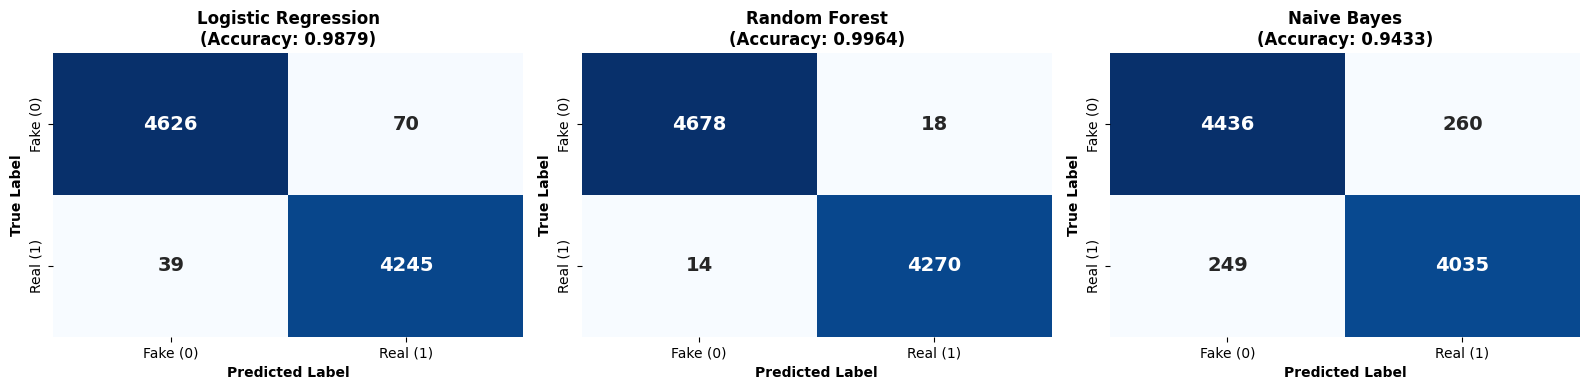


Logistic Regression Confusion Matrix Analysis:
--------------------------------------------------
True Negatives (TN):  4626 (Correctly predicted FAKE)
False Positives (FP):   70 (FAKE predicted as REAL)
False Negatives (FN):   39 (REAL predicted as FAKE)
True Positives (TP):  4245 (Correctly predicted REAL)

Random Forest Confusion Matrix Analysis:
--------------------------------------------------
True Negatives (TN):  4678 (Correctly predicted FAKE)
False Positives (FP):   18 (FAKE predicted as REAL)
False Negatives (FN):   14 (REAL predicted as FAKE)
True Positives (TP):  4270 (Correctly predicted REAL)

Naive Bayes Confusion Matrix Analysis:
--------------------------------------------------
True Negatives (TN):  4436 (Correctly predicted FAKE)
False Positives (FP):  260 (FAKE predicted as REAL)
False Negatives (FN):  249 (REAL predicted as FAKE)
True Positives (TP):  4035 (Correctly predicted REAL)


In [152]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (model_name, y_pred) in enumerate(zip(
    ['Logistic Regression', 'Random Forest', 'Naive Bayes'],
    [y_pred_lr, y_pred_rf, y_pred_nb]
)):
    cm = confusion_matrix(y_test, y_pred)

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Fake (0)', 'Real (1)'],
                yticklabels=['Fake (0)', 'Real (1)'],
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_title(f'{model_name}\n(Accuracy: {results[model_name]["accuracy"]:.4f})',
                        fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('True Label', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed metrics for each model
for model_name in ['Logistic Regression', 'Random Forest', 'Naive Bayes']:
    print(f"\n{model_name} Confusion Matrix Analysis:")
    print("-" * 50)

    if model_name == 'Logistic Regression':
        y_pred = y_pred_lr
    elif model_name == 'Random Forest':
        y_pred = y_pred_rf
    else:
        y_pred = y_pred_nb

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"True Negatives (TN):  {tn:4d} (Correctly predicted FAKE)")
    print(f"False Positives (FP): {fp:4d} (FAKE predicted as REAL)")
    print(f"False Negatives (FN): {fn:4d} (REAL predicted as FAKE)")
    print(f"True Positives (TP):  {tp:4d} (Correctly predicted REAL)")


In [159]:
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)
y_pred_lr_proba = lr_model.predict_proba(X_test)
y_test_array = y_test.values

# Create a dataframe with predictions
misclassified_df = pd.DataFrame({
    'actual': y_test_array,
    'predicted': y_pred_lr,
    'fake_prob': y_pred_lr_proba[:, 0],
    'real_prob': y_pred_lr_proba[:, 1],
    'confidence': np.max(y_pred_lr_proba, axis=1)
})

# Get test indices
# Better approach: recreate test data
X_train_indices, X_test_indices = train_test_split(
    range(len(df)),
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Add original data to misclassified_df
misclassified_df['original_index'] = X_test_indices
misclassified_df['title'] = df.iloc[X_test_indices]['title'].values
misclassified_df['text'] = df.iloc[X_test_indices]['text'].values

# Filter only misclassified
misclassified_only = misclassified_df[misclassified_df['actual'] != misclassified_df['predicted']]

# Sort by confidence (model was most confident but wrong)
misclassified_only = misclassified_only.sort_values('confidence', ascending=False)

print(f"\nTotal misclassified articles: {len(misclassified_only)}")
print(f"Misclassification rate: {len(misclassified_only)/len(misclassified_df)*100:.2f}%\n")

# Display top 15 misclassified articles
print("Top 15 Misclassified Articles (Logistic Regression):")
print("="*60)

for idx, (i, row) in enumerate(misclassified_only.head(15).iterrows(), 1):
    print(f"\n{idx}. ARTICLE #{row['original_index']}")
    print(f"   {'─'*56}")
    print(f"   TITLE: {row['title'][:70]}...")
    print(f"   ACTUAL: {row['actual'].upper()}")
    print(f"   PREDICTED: {row['predicted'].upper()}")
    print(f"   CONFIDENCE: {row['confidence']:.4f}")
    print(f"   FAKE PROB: {row['fake_prob']:.4f} | REAL PROB: {row['real_prob']:.4f}")
    print(f"   TEXT PREVIEW: {row['text'][:100]}...")


Total misclassified articles: 109
Misclassification rate: 1.21%

Top 15 Misclassified Articles (Logistic Regression):

1. ARTICLE #37517
   ────────────────────────────────────────────────────────
   TITLE: N. KOREA’S LATEST MISSILE LAUNCH Aimed At Testing Carrying “Large Scal...
   ACTUAL: FAKE
   PREDICTED: REAL
   CONFIDENCE: 0.9793
   FAKE PROB: 0.0207 | REAL PROB: 0.9793
   TEXT PREVIEW: North Korea said on Monday it had successfully conducted a newly developed mid-to-long range missile...

2. ARTICLE #38675
   ────────────────────────────────────────────────────────
   TITLE: BREAKING: Republican Majority House Caves To Obama…Narrowly Passes TPA...
   ACTUAL: FAKE
   PREDICTED: REAL
   CONFIDENCE: 0.9390
   FAKE PROB: 0.0610 | REAL PROB: 0.9390
   TEXT PREVIEW: Just when you thought the 2014 election results would provide America with some checks and balances ...

3. ARTICLE #42768
   ────────────────────────────────────────────────────────
   TITLE: BREAKING: US Appeals Court D

In [161]:
feature_names = np.array(vectorizer.get_feature_names_out())

#### Features Resposible for Prediction


In [162]:
# 1. LOGISTIC REGRESSION

print("\n1. LOGISTIC REGRESSION - Top Features by Coefficient")


coefficients = lr_model.coef_[0]
top_positive_idx = np.argsort(coefficients)[-20:]
top_negative_idx = np.argsort(coefficients)[:20]

print("\nTop 20 Features Associated with REAL NEWS ")
real_features = pd.DataFrame({
    'Feature': feature_names[top_positive_idx],
    'Coefficient': coefficients[top_positive_idx]
}).sort_values('Coefficient', ascending=False)

print(real_features.to_string(index=False))

print("\nTop 20 Features Associated with FAKE NEWS")
fake_features = pd.DataFrame({
    'Feature': feature_names[top_negative_idx],
    'Coefficient': coefficients[top_negative_idx]
}).sort_values('Coefficient')

print(fake_features.to_string(index=False))

# 2. RANDOM FOREST

print("\n. RANDOM FOREST ")


rf_importances = rf_model.feature_importances_
top_rf_idx = np.argsort(rf_importances)[-30:]

rf_importance_df = pd.DataFrame({
    'Feature': feature_names[top_rf_idx],
    'Importance': rf_importances[top_rf_idx]
}).sort_values('Importance', ascending=False)

print(rf_importance_df.to_string(index=False))

# 3. NAIVE BAYES

print("\n\n3. NAIVE BAYES - Feature Log Probabilities (Top 30)")
print("─" * 60)

# Get log probabilities
nb_log_prob_diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]
top_nb_idx = np.argsort(nb_log_prob_diff)[-30:]

nb_importance_df = pd.DataFrame({
    'Feature': feature_names[top_nb_idx],
    'Log Prob Diff': nb_log_prob_diff[top_nb_idx]
}).sort_values('Log Prob Diff', ascending=False)

print(nb_importance_df.to_string(index=False))



1. LOGISTIC REGRESSION - Top Features by Coefficient
────────────────────────────────────────────────────────────

Top 20 Features Associated with REAL NEWS (Positive Coefficients):
           Feature  Coefficient
           reuters    21.782979
              said    15.694558
washington reuters     9.141358
  president donald     5.629934
        washington     5.125606
         wednesday     4.783625
 reuters president     4.724351
           tuesday     4.342698
          thursday     4.292423
               edt     4.017380
            friday     3.880154
               nov     3.664023
      presidential     3.510040
            monday     3.494334
          minister     3.371499
               don     3.269618
  president barack     3.140647
    said statement     2.932876
         spokesman     2.921805
      told reuters     2.875345

Top 20 Features Associated with FAKE NEWS (Negative Coefficients):
        Feature  Coefficient
          video    -9.226457
          image    

#### Visualisation

<Figure size 640x480 with 0 Axes>

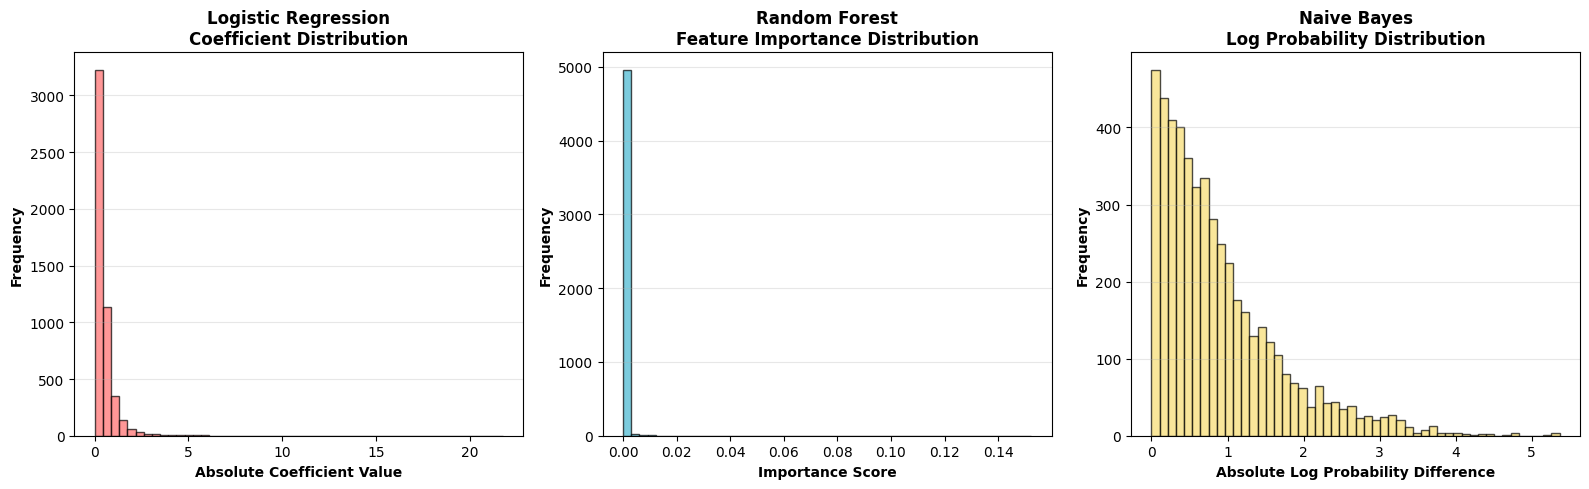

In [163]:
# Logistic Regression
top_lr_idx = np.argsort(np.abs(coefficients))[-15:]
axes[0].barh(range(len(top_lr_idx)), np.abs(coefficients[top_lr_idx]),
             color='#FF6B6B', edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_lr_idx)))
axes[0].set_yticklabels(feature_names[top_lr_idx], fontsize=9)
axes[0].set_xlabel('Absolute Coefficient', fontweight='bold')
axes[0].set_title('Logistic Regression\nTop 15 Features', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Random Forest
top_rf_idx_15 = np.argsort(rf_importances)[-15:]
axes[1].barh(range(len(top_rf_idx_15)), rf_importances[top_rf_idx_15],
             color='#45B7D1', edgecolor='black', linewidth=1.5)
axes[1].set_yticks(range(len(top_rf_idx_15)))
axes[1].set_yticklabels(feature_names[top_rf_idx_15], fontsize=9)
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('Random Forest\nTop 15 Features', fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

# Naive Bayes
top_nb_idx_15 = np.argsort(np.abs(nb_log_prob_diff))[-15:]
axes[2].barh(range(len(top_nb_idx_15)), np.abs(nb_log_prob_diff[top_nb_idx_15]),
             color='#F7DC6F', edgecolor='black', linewidth=1.5)
axes[2].set_yticks(range(len(top_nb_idx_15)))
axes[2].set_yticklabels(feature_names[top_nb_idx_15], fontsize=9)
axes[2].set_xlabel('Absolute Log Prob Diff', fontweight='bold')
axes[2].set_title('Naive Bayes\nTop 15 Features', fontweight='bold', fontsize=11)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


# Visualization 4: Feature Importance Distribution

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Logistic Regression coefficients distribution
axes[0].hist(np.abs(coefficients), bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Absolute Coefficient Value', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Logistic Regression\nCoefficient Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Random Forest importance distribution
axes[1].hist(rf_importances, bins=50, color='#45B7D1', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Random Forest\nFeature Importance Distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Naive Bayes log prob distribution
axes[2].hist(np.abs(nb_log_prob_diff), bins=50, color='#F7DC6F', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Absolute Log Probability Difference', fontweight='bold')
axes[2].set_ylabel('Frequency', fontweight='bold')
axes[2].set_title('Naive Bayes\nLog Probability Distribution', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [166]:
# STEP 13: SUMMARY STATISTICS

print(f"\nTotal features extracted: {len(feature_names)}")
print(f"\nLogistic Regression:")
print(f"  - Avg absolute coefficient: {np.mean(np.abs(coefficients)):.6f}")
print(f"  - Max coefficient (REAL): {np.max(coefficients):.6f}")
print(f"  - Min coefficient (FAKE): {np.min(coefficients):.6f}")

print(f"\nRandom Forest:")
print(f"  - Avg importance: {np.mean(rf_importances):.6f}")
print(f"  - Max importance: {np.max(rf_importances):.6f}")
print(f"  - Top feature: {feature_names[np.argmax(rf_importances)]} ({np.max(rf_importances):.6f})")

print(f"\nNaive Bayes:")
print(f"  - Avg log prob diff: {np.mean(np.abs(nb_log_prob_diff)):.6f}")
print(f"  - Max log prob diff: {np.max(np.abs(nb_log_prob_diff)):.6f}")
print(f"  - Top feature: {feature_names[np.argmax(np.abs(nb_log_prob_diff))]} ({np.max(np.abs(nb_log_prob_diff)):.6f})")



Total features extracted: 5000

Logistic Regression:
  - Avg absolute coefficient: 0.471492
  - Max coefficient (REAL): 21.782979
  - Min coefficient (FAKE): -9.226457

Random Forest:
  - Avg importance: 0.000200
  - Max importance: 0.152373
  - Top feature: reuters (0.152373)

Naive Bayes:
  - Avg log prob diff: 0.888304
  - Max log prob diff: 5.367420
  - Top feature: washington reuters (5.367420)


In [167]:
import pickle

# Save Logistic Regression model
with open('model_lr.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save Random Forest model
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save Naive Bayes model
with open('model_nb.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Save TF-IDF Vectorizer
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✓ All models saved successfully!")

✓ All models saved successfully!


In [168]:
from google.colab import files

# Download models
files.download('model_lr.pkl')
files.download('model_rf.pkl')
files.download('model_nb.pkl')
files.download('vectorizer.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>